In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [77]:
data = pd.read_csv("winequality-red.csv")
data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [78]:
data.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

In [79]:
data.shape

(1599, 12)

In [80]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [81]:
data.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [82]:
data=data.drop_duplicates()
data.shape

(1359, 12)

In [83]:
data.quality.value_counts()

quality
5    577
6    535
7    167
4     53
8     17
3     10
Name: count, dtype: int64

C:\Users\DRAKSHAYANI\AppData\Local\Temp\ipykernel_26772\2153137126.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = 'quality',data=data,palette = 'rainbow')


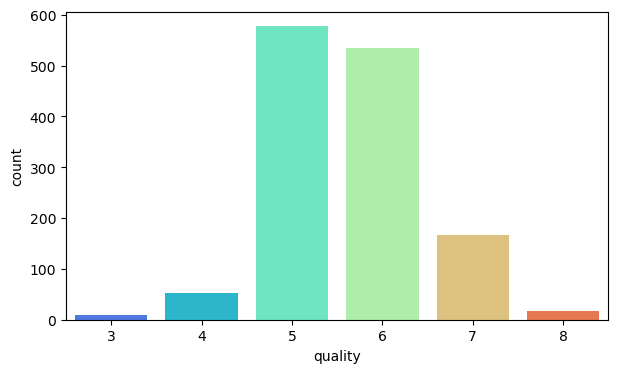

In [84]:
plt.figure(figsize=(7,4))
sns.countplot(x = 'quality',data=data,palette = 'rainbow')
plt.show()

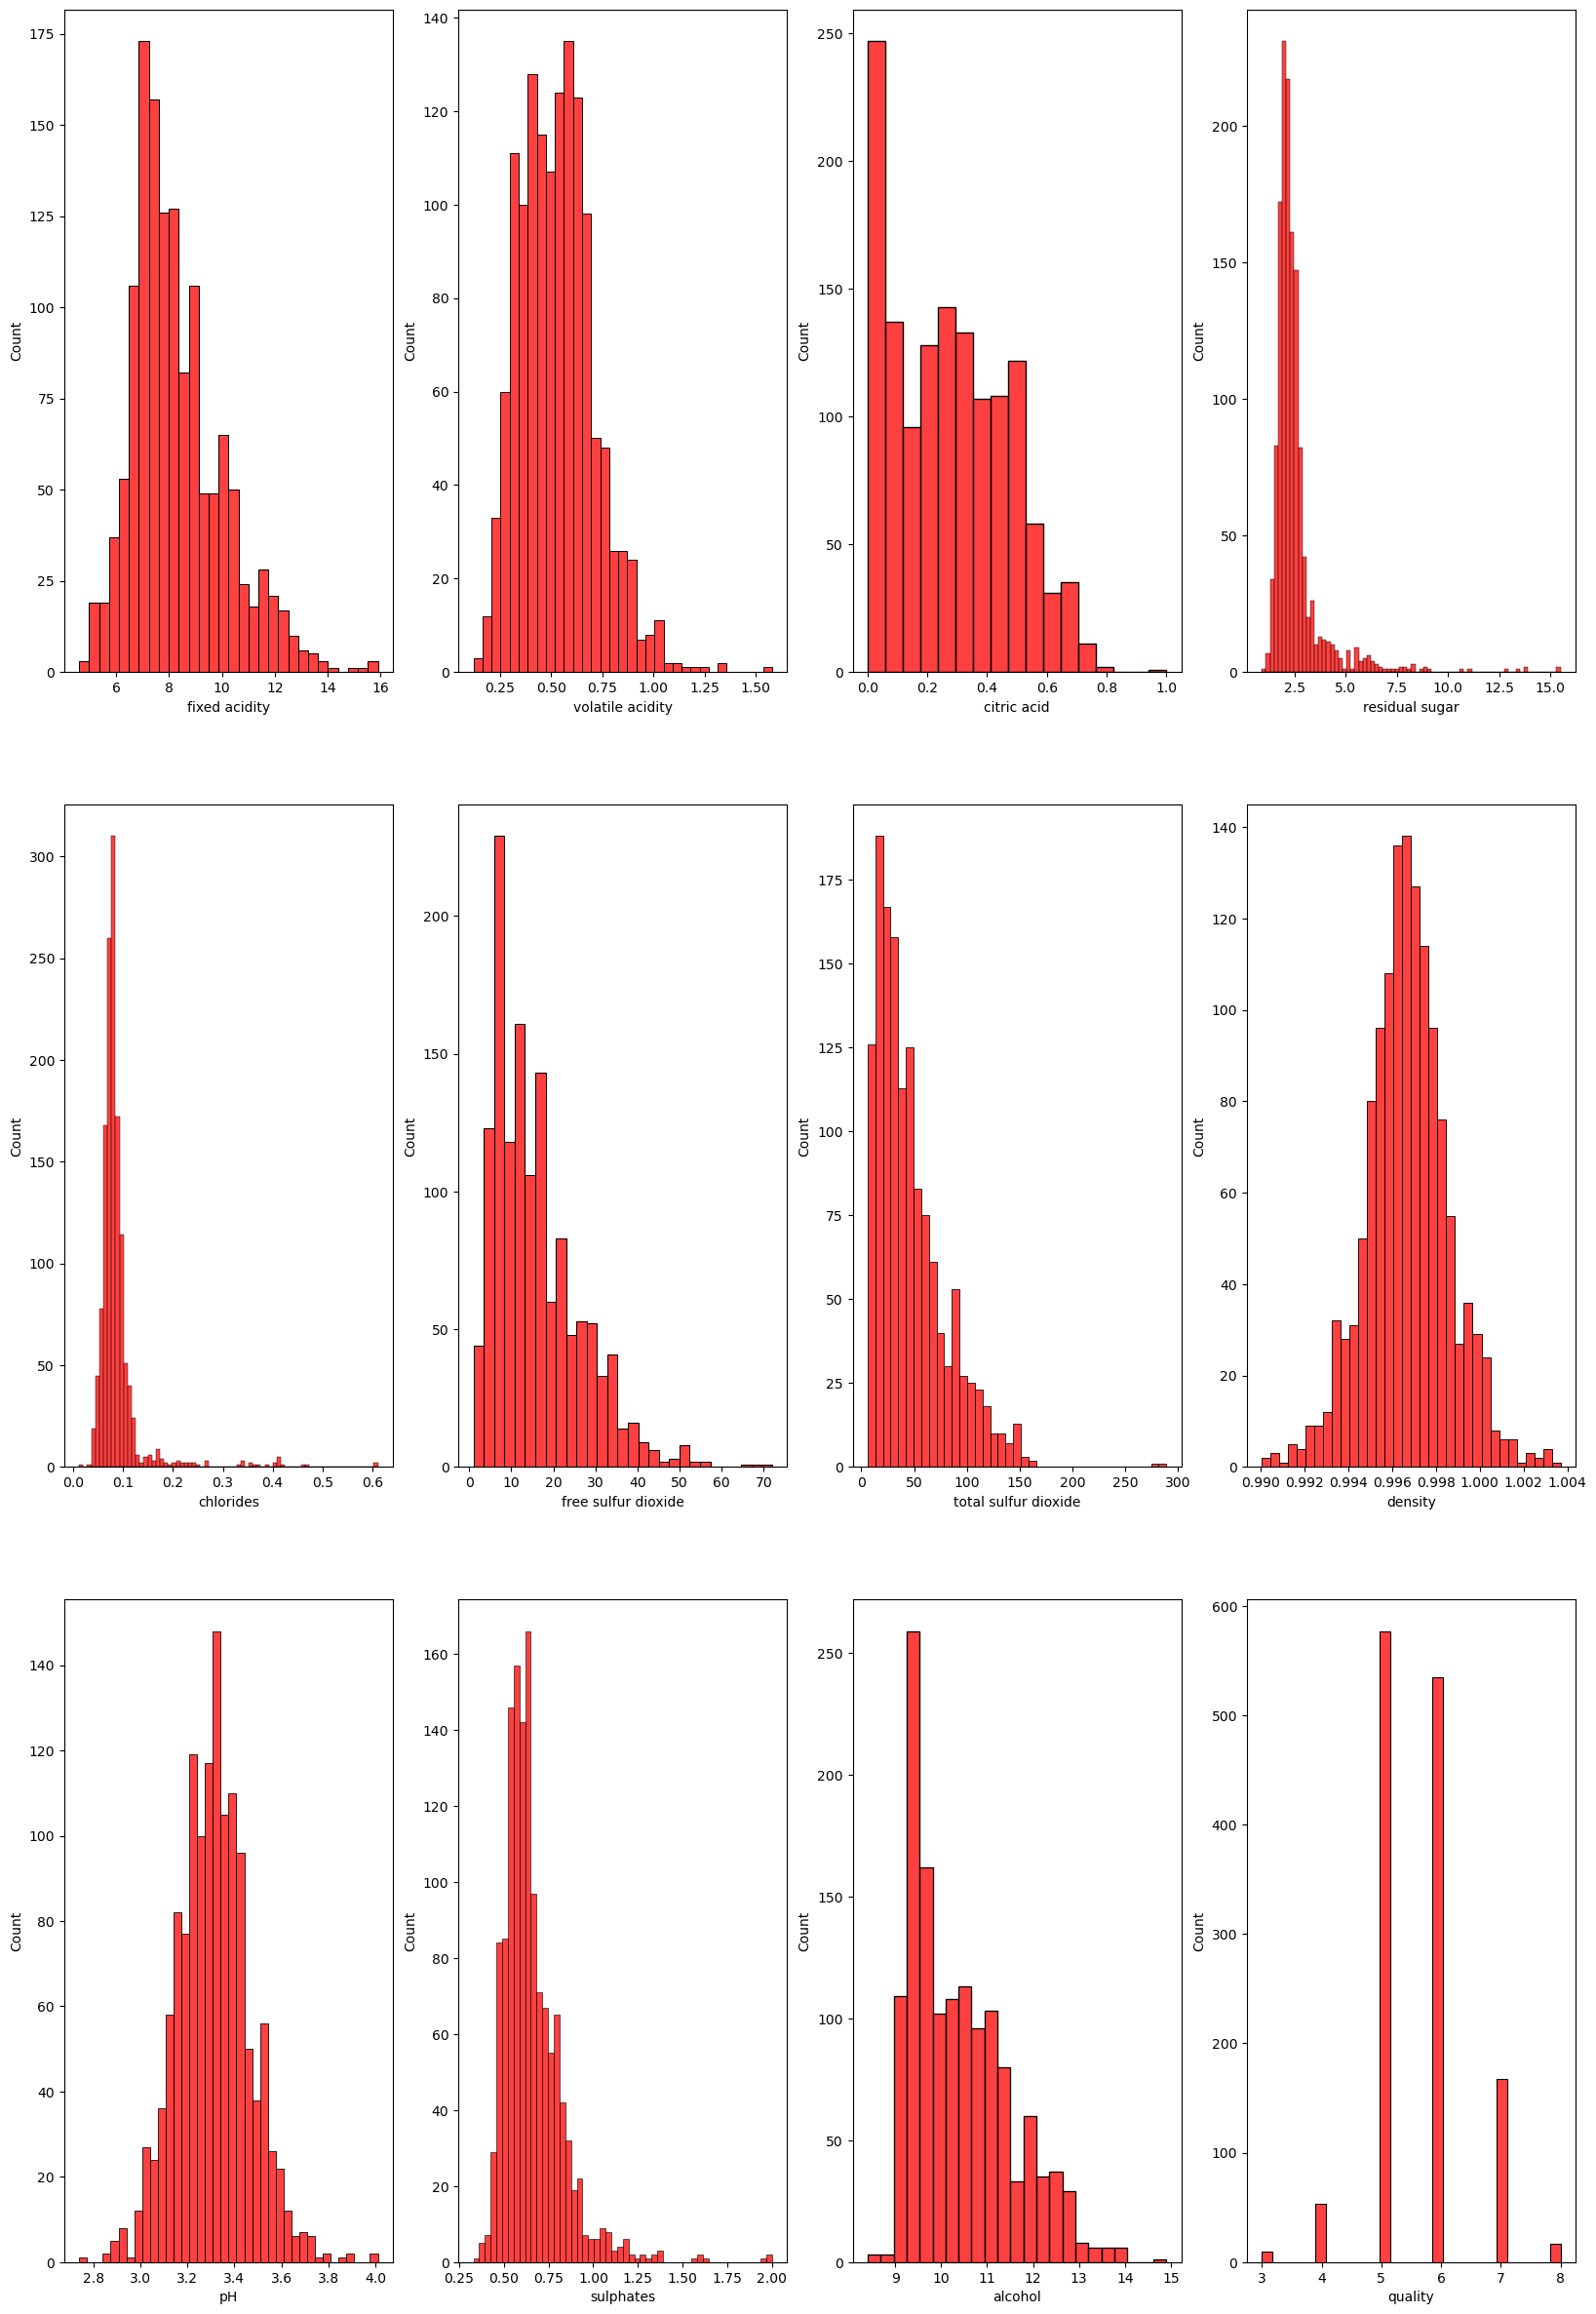

In [85]:
color = sns.color_palette("pastel")

fig, ax1 = plt.subplots(3,4, figsize=(20,30))
k = 0
columns = list(data.columns)
for i in range(3):
    for j in range(4):
            sns.histplot(data[columns[k]], ax = ax1[i][j], color = 'red')
            k += 1
plt.show()

In [86]:
data.columns


Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

In [87]:
# apply log on features
data ['residual sugar']=np.log(data['residual sugar'])
data ['chlorides']=np.log(data['chlorides'])
data ['free sulfur dioxide']=np.log(data['free sulfur dioxide'])
data ['total sulfur dioxide']=np.log(data['total sulfur dioxide'])
data ['sulphates']=np.log(data['sulphates'])



In [88]:
data.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

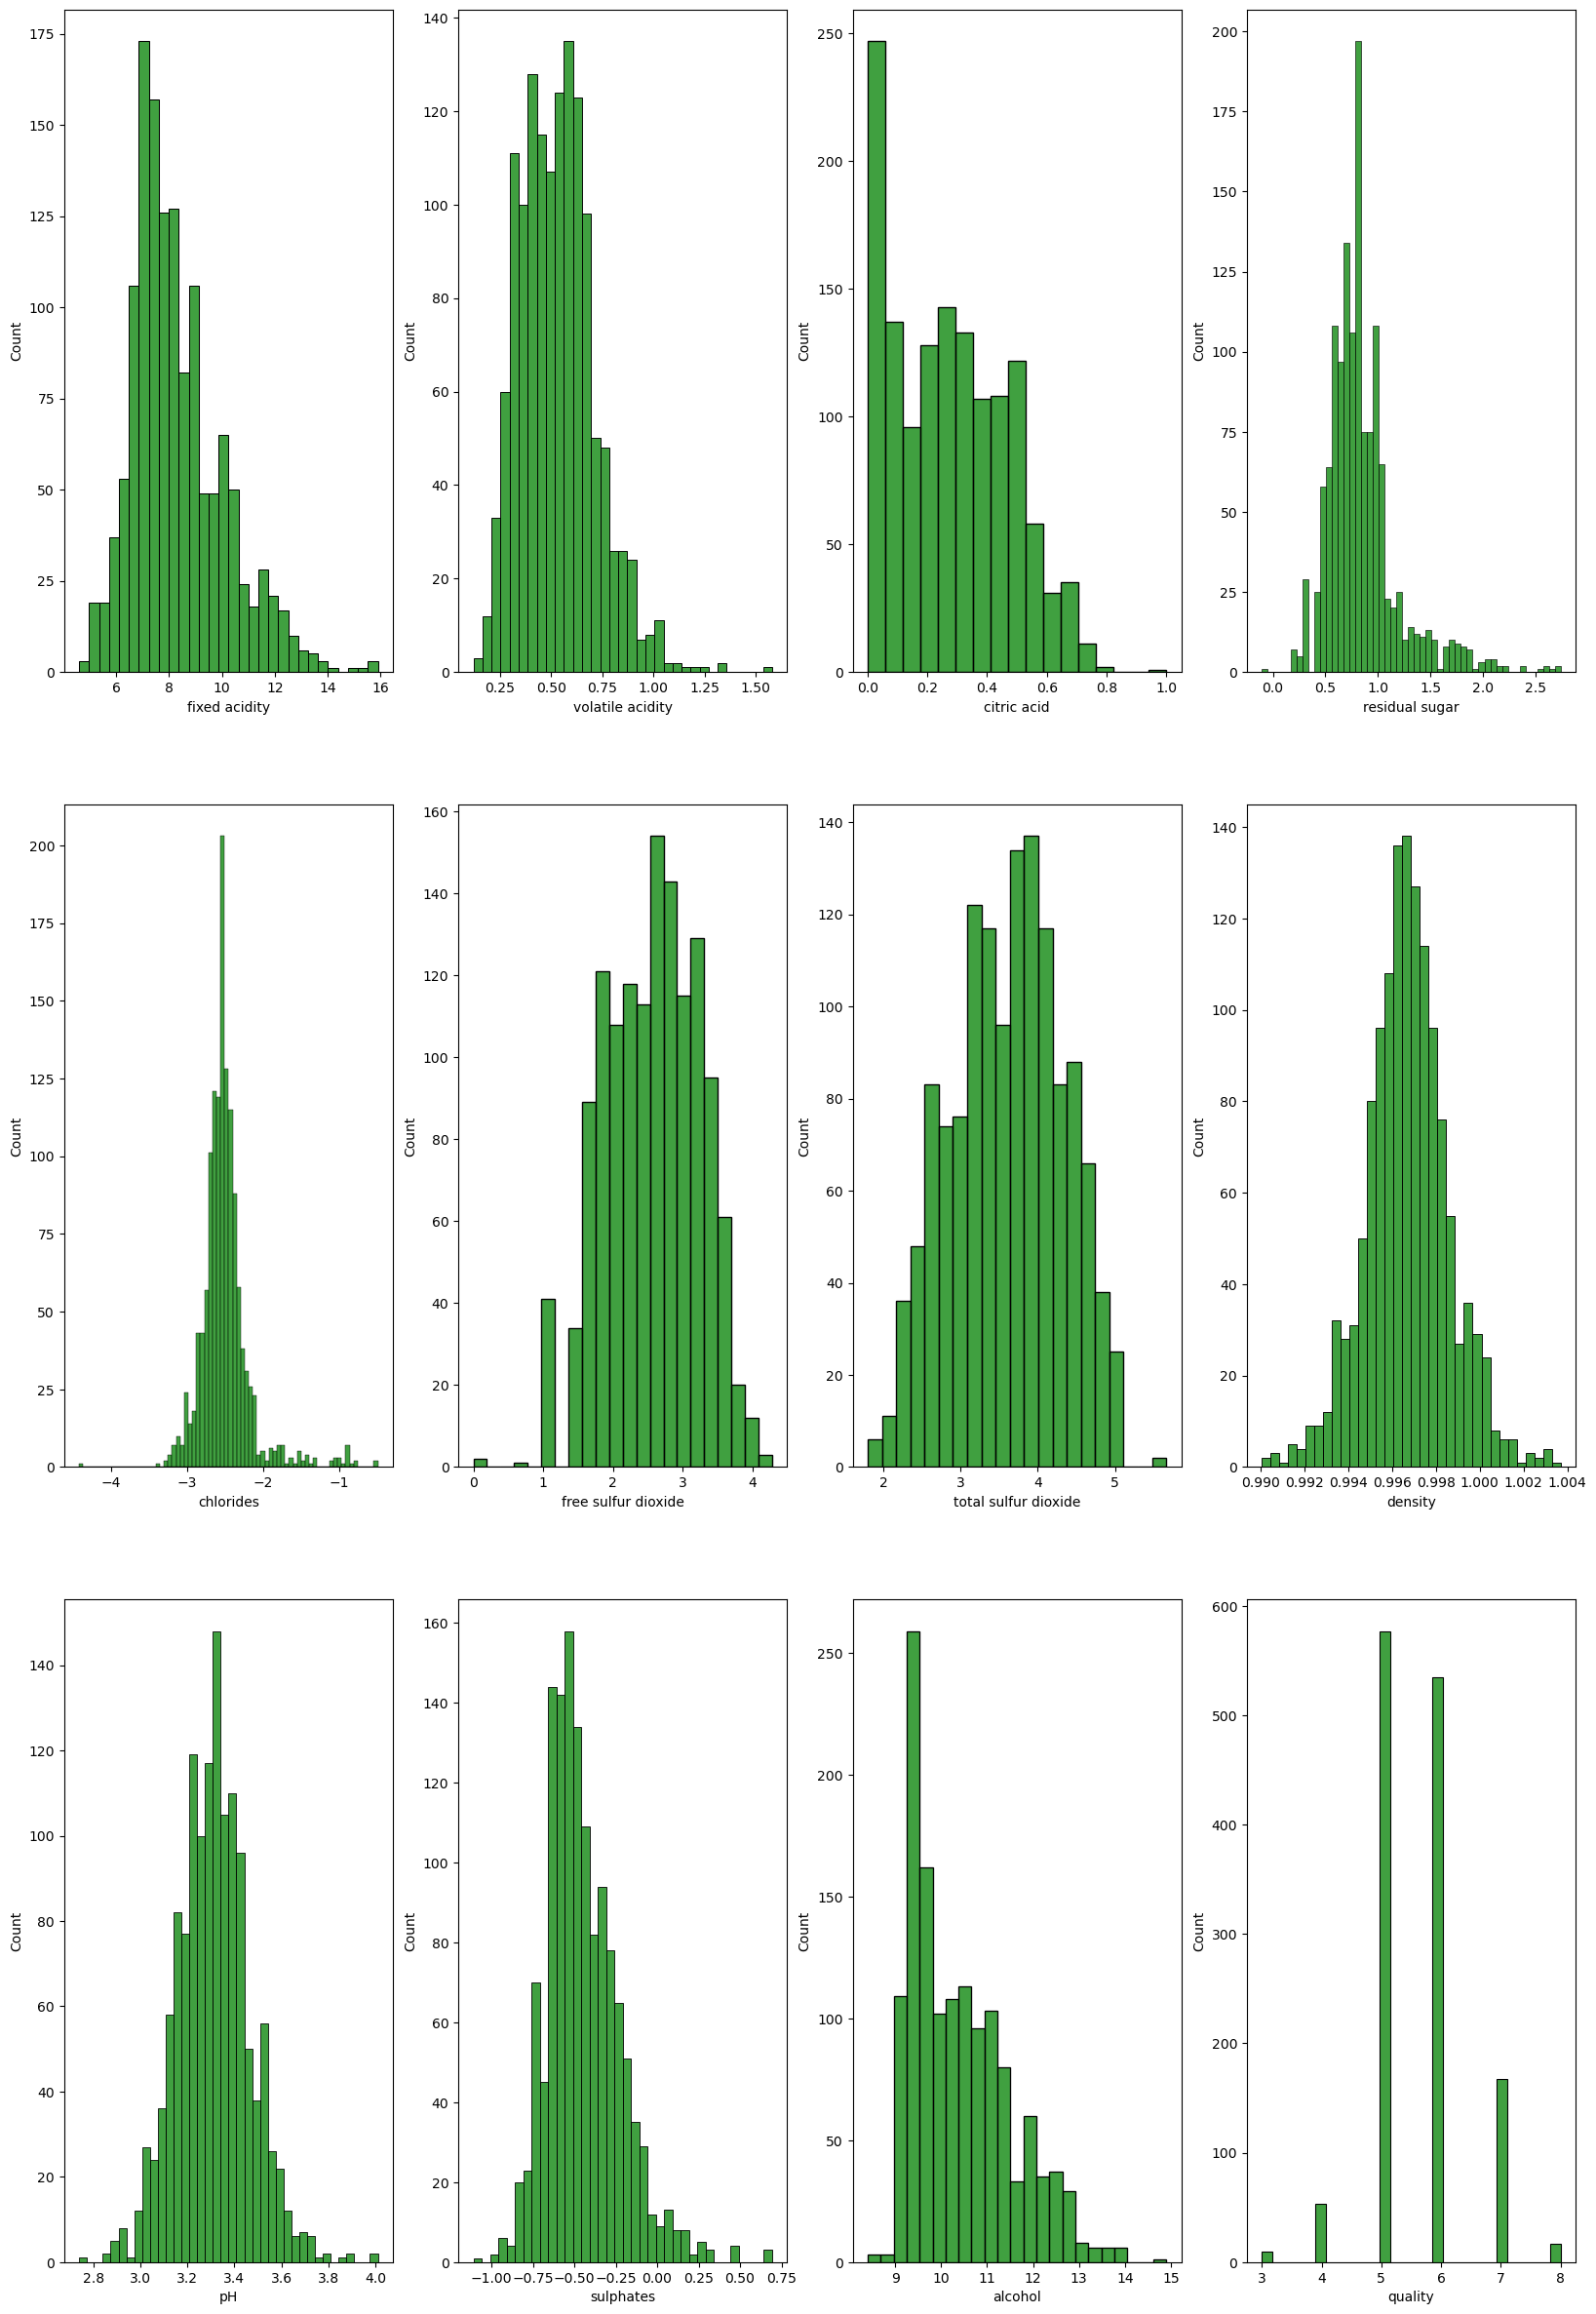

In [89]:
color = sns.color_palette("pastel")

fig, ax1 = plt.subplots(3,4, figsize=(20,30))
k = 0
columns = list(data.columns)
for i in range(3):
    for j in range(4):
            sns.histplot(data[columns[k]], ax = ax1[i][j], color = 'green')
            k += 1
plt.show()

In [90]:
X= data.drop('quality', axis=1)
X.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.4,0.70,0.00,0.641854,-2.577022,2.397895,3.526361,0.9978,3.51,-0.579818,9.4
1,7.8,0.88,0.00,0.955511,-2.322788,3.218876,4.204693,0.9968,3.20,-0.385662,9.8
2,7.8,0.76,0.04,0.832909,-2.385967,2.708050,3.988984,0.9970,3.26,-0.430783,9.8
3,11.2,0.28,0.56,0.641854,-2.590267,2.833213,4.094345,0.9980,3.16,-0.544727,9.8
5,7.4,0.66,0.00,0.587787,-2.590267,2.564949,3.688879,0.9978,3.51,-0.579818,9.4


In [91]:
y= data['quality']
y.head()

0    5
1    5
2    5
3    6
5    5
Name: quality, dtype: int64

In [92]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size =0.2,random_state=0)
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((1087, 11), (272, 11), (1087,), (272,))

In [93]:
from imblearn.over_sampling import SMOTE
from collections import Counter
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

print("After SMOTE:", Counter(y_resampled))

After SMOTE: Counter({5: 464, 7: 464, 6: 464, 4: 464, 8: 464, 3: 464})


In [94]:
X_resampled.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
count,2784.000000,2784.000000,2784.000000,2784.000000,2784.000000,2784.000000,2784.000000,2784.000000,2784.000000,2784.000000,2784.000000
mean,8.438549,0.578968,0.283609,0.851390,-2.497219,2.379871,3.363335,0.996543,3.318203,-0.445934,10.689219
std,1.665734,0.243368,0.192993,0.316903,0.319252,0.654604,0.653392,0.001884,0.142806,0.217742,1.219417
min,4.600000,0.120000,0.000000,0.182322,-4.422849,0.000000,1.791759,0.990200,2.740000,-1.108663,8.400000
25%,7.251594,0.395044,0.100000,0.650401,-2.672451,1.791759,2.833213,0.995259,3.227095,-0.598052,9.676075
50%,8.130327,0.540000,0.294297,0.776970,-2.551046,2.411939,3.332205,0.996567,3.312549,-0.461817,10.500000
75%,9.507558,0.700504,0.440000,0.955511,-2.389066,2.849076,3.856893,0.997860,3.397685,-0.292182,11.634810
max,15.600000,1.580000,1.000000,2.734368,-0.492658,4.276666,5.105945,1.003690,4.010000,0.693147,14.000000


In [95]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_fit = scaler.fit_transform(X_resampled)
X_test = scaler.transform(X_test)

In [96]:
X_train_fit_df = pd.DataFrame(X_train_fit, columns = X_resampled.columns)
X_train_fit_df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
count,2.784000e+03,2.784000e+03,2.784000e+03,2.784000e+03,2.784000e+03,2.784000e+03,2.784000e+03,2.784000e+03,2.784000e+03,2.784000e+03,2.784000e+03
mean,4.721638e-16,2.245968e-16,7.146263e-17,-1.276118e-18,-4.185668e-16,6.125368e-17,-1.020895e-16,2.168380e-14,-1.898864e-15,2.450147e-16,7.146263e-16
std,1.000180e+00,1.000180e+00,1.000180e+00,1.000180e+00,1.000180e+00,1.000180e+00,1.000180e+00,1.000180e+00,1.000180e+00,1.000180e+00,1.000180e+00
min,-2.304833e+00,-1.886242e+00,-1.469792e+00,-2.111653e+00,-6.032772e+00,-3.636240e+00,-2.405689e+00,-3.367936e+00,-4.049591e+00,-3.044196e+00,-1.877643e+00
25%,-7.126997e-01,-7.558824e-01,-9.515452e-01,-6.343429e-01,-5.489790e-01,-8.985843e-01,-8.114835e-01,-6.819641e-01,-6.380937e-01,-6.987425e-01,-8.309922e-01
50%,-1.850702e-01,-1.601486e-01,5.539256e-02,-2.348787e-01,-1.686343e-01,4.899696e-02,-4.765295e-02,1.235304e-02,-3.959918e-02,-7.296043e-02,-1.551997e-01
75%,6.418800e-01,4.994808e-01,8.104934e-01,3.286174e-01,3.388303e-01,7.169054e-01,7.555134e-01,6.990611e-01,5.566728e-01,7.062447e-01,7.755841e-01
max,4.300049e+00,4.113988e+00,3.712675e+00,5.942879e+00,6.280056e+00,2.898142e+00,2.667500e+00,3.794439e+00,4.845179e+00,5.232283e+00,2.715539e+00


## Apply Linerar Regression

In [97]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
model_lr = LogisticRegression()
model_lr.fit(X_train_fit, y_resampled)
y_predict_lr=model_lr.predict(X_test)
accuracy_lr = accuracy_score(y_test,y_predict_lr)
print(f"Accuracy pf LR:",round(accuracy_lr,2)*100,"%")

Accuracy pf LR: 45.0 %


## Apply SVM

In [98]:
from sklearn.svm import SVC
model_svc = SVC(kernel='rbf')
model_svc.fit(X_train_fit, y_resampled)
y_predict_svc=model_svc.predict(X_test)
accuracy_svc = accuracy_score(y_test,y_predict_svc)
print(f"Accuracy of SVC:",round(accuracy_svc,2)*100,"%")

Accuracy of SVC: 51.0 %


##  Apply Decision Tree

In [99]:
from sklearn.tree import DecisionTreeClassifier
model_dt = DecisionTreeClassifier()
model_dt.fit(X_train_fit, y_resampled)
y_predict_dt=model_dt.predict(X_test)
accuracy_dt = accuracy_score(y_test,y_predict_dt)
print(f"Accuracy of DT:",round(accuracy_dt,2)*100,"%")

Accuracy of DT: 45.0 %


In [100]:
from sklearn.neighbors import KNeighborsClassifier
model_knn =KNeighborsClassifier()
model_knn.fit(X_train_fit, y_resampled)
y_predict_knn=model_knn.predict(X_test)
accuracy_knn = accuracy_score(y_test,y_predict_knn)
print(f"Accuracy of KNN:",round(accuracy_knn,2)*100,"%")

Accuracy of KNN: 41.0 %


##  Apply Random Forest

In [101]:
from sklearn.ensemble import RandomForestClassifier
model_rf =RandomForestClassifier()
model_rf.fit(X_train_fit, y_resampled)
y_predict_rf=model_rf.predict(X_test)
accuracy_rf= accuracy_score(y_test,y_predict_rf)
print(f"Accuracy of RF:",round(accuracy_rf,2)*100,"%")

Accuracy of RF: 55.00000000000001 %


In [103]:
# Save RF model and scaler parameters

import pickle

pickle.dump(model_rf, open('model_rf.pkl', 'wb'))
pickle.dump(scaler, open('scaler.pkl', 'wb'))

In [104]:
import numpy as np
import pickle

# Load saved model and scaler
with open("model_rf.pkl", "rb") as f:
    model = pickle.load(f)

with open("scaler.pkl", "rb") as f:
    scaler = pickle.load(f)

# List of feature names in correct order
feature_names = [
    'fixed acidity', 'volatile acidity', 'citric acid', 
    'residual sugar','chlorides', 'free sulfur dioxide', 
    'total sulfur dioxide', 'density',
    'pH', 'sulphates', 'alcohol'
]

# Collect input values from user
print("Enter the following details for prediction:")

user_values = []
for feature in feature_names:
    val = float(input(f"Enter {feature}: "))
    user_values.append(val)

# Convert to array and reshape
input_data = np.array(user_values).reshape(1, -1)

# Scale using the fitted scaler
scaled_data = scaler.transform(input_data)

# Predict
prediction = model.predict(scaled_data)

print(f"\nPredicted Wine Quality: {prediction[0]}")

Enter the following details for prediction:

Predicted Wine Quality: 6


c:\Users\DRAKSHAYANI\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
